# Credit Card Fraud Detection - XGBoost

This notebook trains a supervised XGBoost classifier as a stronger benchmark against Logistic Regression and the unsupervised Autoencoder. XGBoost is not an unsupervised method; it uses the `Class` label during training.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "creditcard_2023.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "creditcard_2023.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(RESULTS_DIR / ".matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42

## Load and prepare data

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.dropna()

X = df.drop(columns=["id", "Class"])
y = df["Class"]

print(df.shape)
print(y.value_counts())

(568630, 31)
Class
0    284315
1    284315
Name: count, dtype: int64


In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Validation:", X_val.shape, y_val.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (398041, 29) {1: 199021, 0: 199020}
Validation: (85294, 29) {0: 42647, 1: 42647}
Test: (85295, 29) {0: 42648, 1: 42647}


## Train XGBoost classifier

In [4]:
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Tune decision threshold on validation set

In [5]:
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
threshold_rows = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision_fraud": precision_score(y_val, y_val_pred, zero_division=0),
        "recall_fraud": recall_score(y_val, y_val_pred, zero_division=0),
        "f1_fraud": f1_score(y_val, y_val_pred, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    })

xgboost_threshold_results = pd.DataFrame(threshold_rows)
xgboost_threshold_results.to_csv(RESULTS_DIR / "xgboost_threshold_results.csv", index=False)

best_threshold_row = xgboost_threshold_results.sort_values(
    ["f1_fraud", "recall_fraud"],
    ascending=False,
).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print("Best validation threshold:", best_threshold)
xgboost_threshold_results

Best validation threshold: 0.4


,threshold,accuracy,precision_fraud,recall_fraud,f1_fraud,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.946128,0.902735,1.000000,0.948881,38052,4595,0,42647
1,0.10,0.972143,0.947227,1.000000,0.972898,40271,2376,0,42647
2,0.15,0.981992,0.965257,0.999977,0.982310,41112,1535,1,42646
3,0.20,0.986857,0.974626,0.999742,0.987024,41537,1110,11,42636
4,0.25,0.989648,0.980576,0.999086,0.989744,41803,844,39,42608
5,0.30,0.991277,0.984887,0.997866,0.991334,41994,653,91,42556
6,0.35,0.992180,0.987890,0.996577,0.992214,42126,521,146,42501
7,0.40,0.992532,0.990221,0.994888,0.992549,42228,419,218,42429
8,0.45,0.992414,0.992057,0.992778,0.992417,42308,339,308,42339
9,0.50,0.991711,0.993574,0.989823,0.991695,42374,273,434,42213


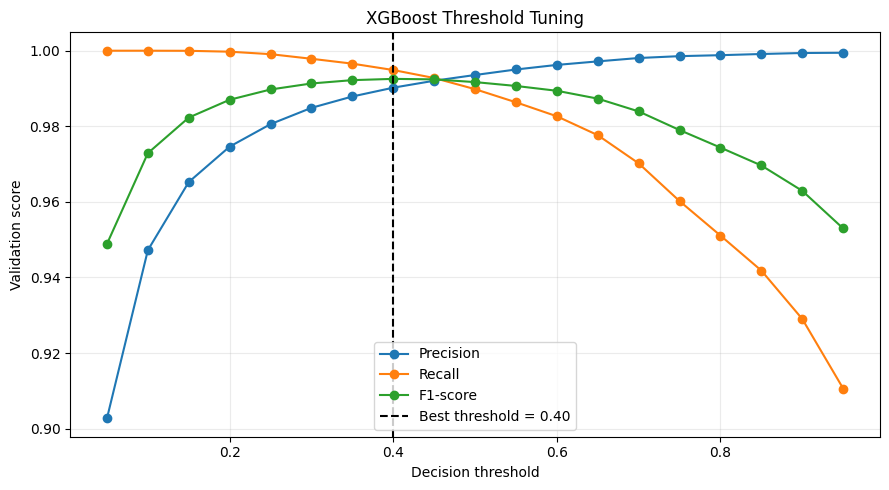

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(xgboost_threshold_results["threshold"], xgboost_threshold_results["precision_fraud"], marker="o", label="Precision")
plt.plot(xgboost_threshold_results["threshold"], xgboost_threshold_results["recall_fraud"], marker="o", label="Recall")
plt.plot(xgboost_threshold_results["threshold"], xgboost_threshold_results["f1_fraud"], marker="o", label="F1-score")
plt.axvline(best_threshold, linestyle="--", color="black", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Validation score")
plt.title("XGBoost Threshold Tuning")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluate on test set

[[42220   428]
 [  242 42405]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     42648
           1       0.99      0.99      0.99     42647

    accuracy                           0.99     85295
   macro avg       0.99      0.99      0.99     85295
weighted avg       0.99      0.99      0.99     85295



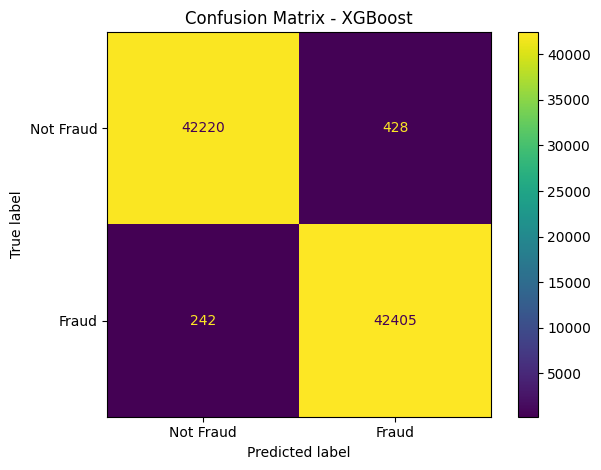

In [7]:
y_test_pred = (y_test_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_test_pred)
report = classification_report(y_test, y_test_pred)

print(cm)
print(report)

with open(RESULTS_DIR / "xgboost_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"],
)
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
xgboost_metrics = pd.DataFrame({
    "Model": ["XGBoost (best F1 threshold)"],
    "Accuracy": [accuracy_score(y_test, y_test_pred)],
    "Precision": [precision_score(y_test, y_test_pred, zero_division=0)],
    "Recall": [recall_score(y_test, y_test_pred, zero_division=0)],
    "F1-score": [f1_score(y_test, y_test_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test, y_test_proba)],
    "PR-AUC": [average_precision_score(y_test, y_test_proba)],
    "Best Threshold Percentile": [np.nan],
    "Threshold": [best_threshold],
})

xgboost_metrics.to_csv(RESULTS_DIR / "xgboost_metrics.csv", index=False)
xgboost_metrics

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Best Threshold Percentile,Threshold
0,XGBoost (best F1 threshold),0.992145,0.990008,0.994326,0.992162,0.999634,0.999563,NaN,0.4


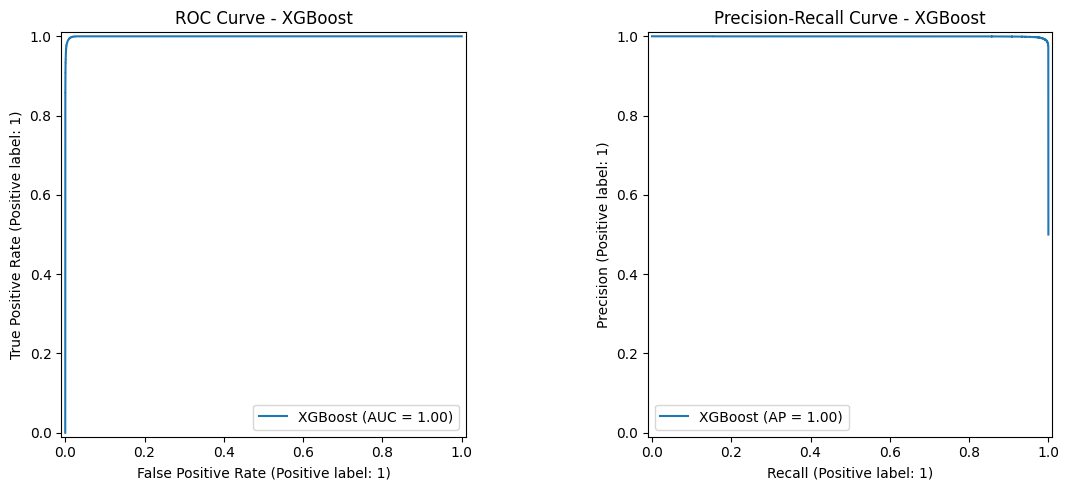

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=axes[0], name="XGBoost")
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=axes[1], name="XGBoost")
axes[0].set_title("ROC Curve - XGBoost")
axes[1].set_title("Precision-Recall Curve - XGBoost")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()

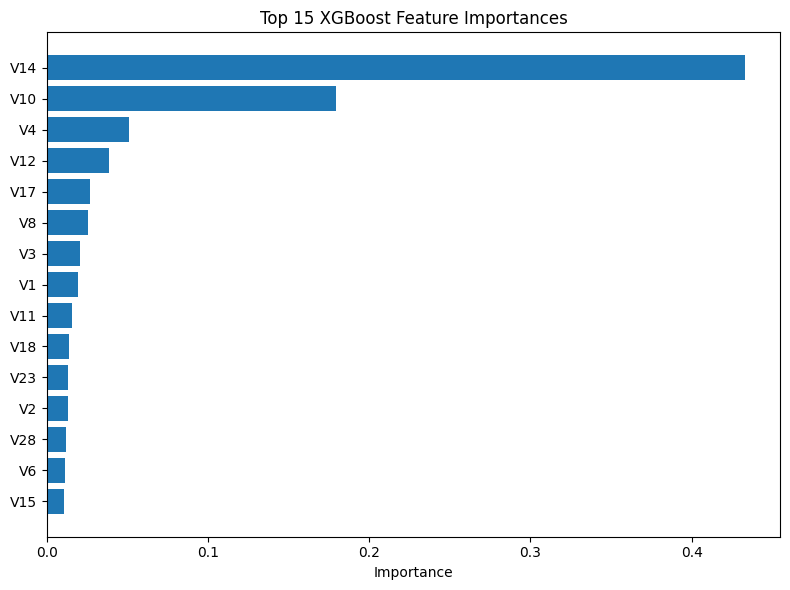

,feature,importance
13,V14,0.433198
9,V10,0.179254
3,V4,0.050753
11,V12,0.038388
16,V17,0.026457
7,V8,0.025215
2,V3,0.020709
0,V1,0.019113
10,V11,0.015740
17,V18,0.013665


In [10]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance.to_csv(RESULTS_DIR / "xgboost_feature_importance.csv", index=False)

top_features = feature_importance.head(15).sort_values("importance")
plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

feature_importance.head(15)

## Update final model comparison

In [11]:
comparison_path = RESULTS_DIR / "model_comparison.csv"
if comparison_path.exists():
    model_comparison = pd.read_csv(comparison_path)
else:
    model_comparison = pd.DataFrame()

model_comparison = model_comparison[
    ~model_comparison.get("Model", pd.Series(dtype=str)).astype(str).str.contains("XGBoost", na=False)
]

model_comparison = pd.concat(
    [model_comparison, xgboost_metrics],
    ignore_index=True,
    sort=False,
)
model_comparison.to_csv(comparison_path, index=False)
model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Best Threshold Percentile,Threshold
0,Logistic Regression,0.964418,0.977253,0.950970,0.963932,0.993444,0.994513,NaN,NaN
1,Autoencoder (best F1 threshold),0.893229,0.943627,0.836425,0.886798,0.945786,0.949521,95.0,0.38493
2,XGBoost (best F1 threshold),0.992145,0.990008,0.994326,0.992162,0.999634,0.999563,NaN,0.40000


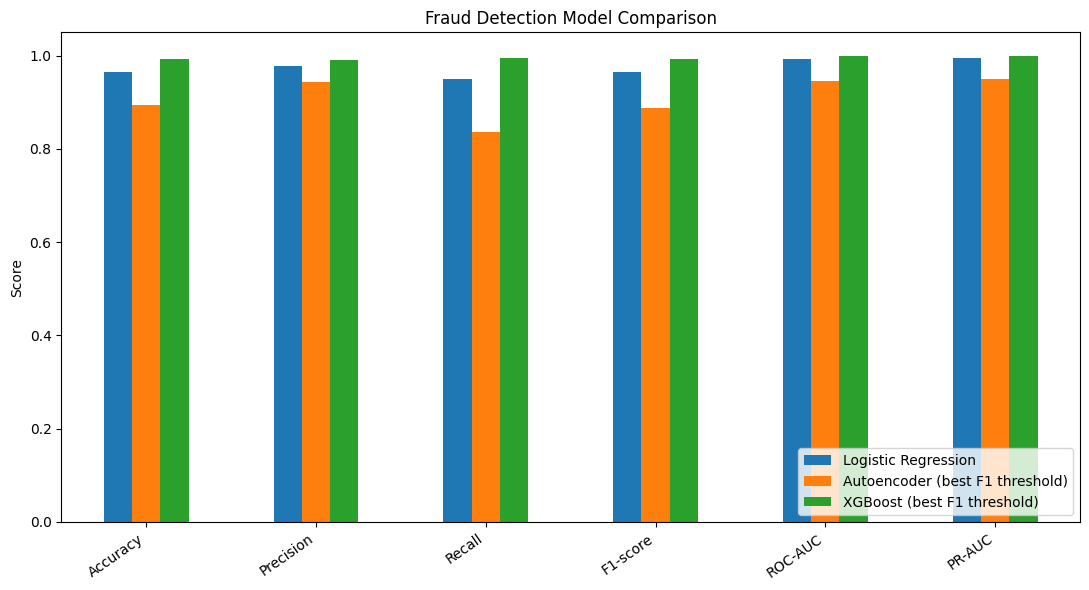

In [12]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
plot_df = model_comparison.set_index("Model")[metrics_to_plot]

ax = plot_df.T.plot(kind="bar", figsize=(11, 6))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Fraud Detection Model Comparison")
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison_metrics.png", dpi=300, bbox_inches="tight")
plt.show()